In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/ColabNotebooks/

/content/drive/MyDrive/ColabNotebooks


##Imports

In [4]:
!pip install h3
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.2 MB/s eta 0:00:00


In [40]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import shap
import folium
import requests
from folium.plugins import MarkerCluster, HeatMap
import matplotlib.pyplot as plt
from branca.colormap import LinearColormap
import seaborn as sns

In [6]:
import h3
import osmnx as ox

##Data Loading and EDA

In [7]:
pd.set_option('display.max_columns', None)

In [8]:
data = pd.read_csv('gk_jamaica_customers.csv', sep = None)

In [9]:
data.head()

,customer_id,age,education_level,marital_status,weekly_household_income_jmd,num_children_under_12,num_teens_at_home,months_as_gk_customer,days_since_last_purchase,mnt_tinned_meats_monthly_jmd,mnt_baked_goods_monthly_jmd,mnt_gk_juices_monthly_jmd,mnt_saltfish_tinned_fish_monthly_jmd,mnt_fresh_produce_monthly_jmd,mnt_cooking_oil_monthly_jmd,buys_gk_ketchup,buys_festival_dumpling_mix,preferred_cooking_oil,num_supermarket_visits_monthly,num_market_vendor_visits_monthly,num_promo_purchases_monthly,uses_route_taxi,has_refrigerator,parish,shopping_location_type,responded_to_gk_promo_tv,responded_to_gk_promo_radio,responded_to_gk_promo_social,gk_brand_loyalty_score,filed_complaint,target_segment
0,1001,35,Tertiary (UWI/CC/HEART),Common-Law,17489,2,2,28,10,3293.73,1889.34,2369.11,1331.81,3727.26,465.48,1,1,Mazola,6,1,4,0,1,Kingston,Corner Shop,1,0,1,5,0,GK Premium
1,1002,40,Secondary (CXC/CSEC),Married,29645,0,1,13,17,2581.46,1446.95,1586.07,1108.04,3481.68,584.06,1,1,Grace,6,3,1,0,1,St. Catherine,Supermarket,1,1,1,4,0,GK Premium
2,1003,31,Secondary (CXC/CSEC),Single,12983,0,0,43,6,1153.51,450.01,616.11,869.49,2171.21,502.14,1,0,Mazola,4,3,5,1,1,St. Catherine,Market/Higglar,1,1,0,4,0,GK Real Value
3,1004,32,Some Secondary,Single,7382,0,3,35,4,1803.64,945.08,896.75,912.75,1633.19,421.51,1,0,Grace,4,4,5,0,1,St. Andrew,Mixed,0,0,0,5,0,GK Real Value
4,1005,52,Primary/All-Age,Single,6035,0,1,16,2,831.54,232.27,230.71,516.67,811.68,228.91,0,1,Other/Generic,1,5,1,1,1,Manchester,Corner Shop,0,1,1,4,0,GK Real Value


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   customer_id                           2500 non-null   int64  
 1   age                                   2500 non-null   int64  
 2   education_level                       2500 non-null   object 
 3   marital_status                        2500 non-null   object 
 4   weekly_household_income_jmd           2500 non-null   int64  
 5   num_children_under_12                 2500 non-null   int64  
 6   num_teens_at_home                     2500 non-null   int64  
 7   months_as_gk_customer                 2500 non-null   int64  
 8   days_since_last_purchase              2500 non-null   int64  
 9   mnt_tinned_meats_monthly_jmd          2500 non-null   float64
 10  mnt_baked_goods_monthly_jmd           2500 non-null   float64
 11  mnt_gk_juices_mon

In [11]:
data.shape

(2500, 31)

In [12]:
data.describe()

,customer_id,age,weekly_household_income_jmd,num_children_under_12,num_teens_at_home,months_as_gk_customer,days_since_last_purchase,mnt_tinned_meats_monthly_jmd,mnt_baked_goods_monthly_jmd,mnt_gk_juices_monthly_jmd,mnt_saltfish_tinned_fish_monthly_jmd,mnt_fresh_produce_monthly_jmd,mnt_cooking_oil_monthly_jmd,buys_gk_ketchup,buys_festival_dumpling_mix,num_supermarket_visits_monthly,num_market_vendor_visits_monthly,num_promo_purchases_monthly,uses_route_taxi,has_refrigerator,responded_to_gk_promo_tv,responded_to_gk_promo_radio,responded_to_gk_promo_social,gk_brand_loyalty_score,filed_complaint
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,2250.50000,40.364400,17340.546400,1.397200,0.759200,28.805600,8.113200,1996.869688,1027.792676,1345.211576,927.345100,2657.252512,477.882116,0.804000,0.458400,3.939600,3.595200,3.895600,0.603600,0.785200,0.536800,0.444000,0.404800,3.690000,0.053600
std,721.83216,10.417592,16046.093534,1.100507,0.862968,17.082381,4.997517,887.250718,767.084228,1205.603247,510.779938,1613.608123,202.830862,0.397048,0.498366,2.618453,2.144289,2.030948,0.489247,0.410766,0.498744,0.496954,0.490951,0.885784,0.225272
min,1001.00000,18.000000,2500.000000,0.000000,0.000000,1.000000,1.000000,222.320000,100.340000,0.000000,129.070000,459.560000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1625.75000,33.000000,6822.250000,1.000000,0.000000,16.000000,4.000000,1231.980000,474.765000,290.492500,608.902500,1584.470000,336.392500,1.000000,0.000000,2.000000,2.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,2250.50000,39.000000,11251.000000,1.000000,1.000000,28.000000,7.000000,1950.740000,789.540000,1019.990000,792.220000,2173.700000,436.140000,1.000000,0.000000,4.000000,3.000000,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,0.000000
75%,2875.25000,47.000000,22553.000000,2.000000,1.000000,41.000000,11.000000,2513.207500,1306.545000,1890.487500,1045.507500,3240.587500,563.707500,1.000000,1.000000,6.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,0.000000
max,3500.00000,72.000000,87575.000000,4.000000,3.000000,84.000000,34.000000,5732.750000,4625.190000,6103.930000,3256.200000,9595.060000,1392.940000,1.000000,1.000000,12.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000


In [13]:
data = data.drop(['customer_id'], axis = 1)

In [14]:
data.duplicated().sum()

np.int64(0)

##Education
*   Secondary (CXC/CSEC) --> Secondary
*   Tertiary (UWI/CC/HEART) --> Tertiary


In [15]:
data['education_level'].unique()

array(['Tertiary (UWI/CC/HEART)', 'Secondary (CXC/CSEC)',
       'Some Secondary', 'Primary/All-Age'], dtype=object)

In [16]:
data['education_level'] = data['education_level'].replace('Tertiary (UWI/CC/HEART)','Tertiary')
data['education_level'] = data['education_level'].replace(['Secondary (CXC/CSEC)', 'Some Secondary'],'Secondary')

In [17]:
data['education_level'].unique()

array(['Tertiary', 'Secondary', 'Primary/All-Age'], dtype=object)

##Marital Status


*   List item
*   List item



In [18]:
data['marital_status'].unique()

array(['Common-Law', 'Married', 'Single', 'Visiting Relationship',
       'Separated'], dtype=object)

In [19]:
data['marital_status'] = data['marital_status'].replace('Common-Law', 'Married')
data['marital_status'] = data['marital_status'].replace('Visiting Relationship','Single')

In [20]:
data['marital_status'].unique()

array(['Married', 'Single', 'Separated'], dtype=object)

In [21]:
from sklearn.preprocessing import OrdinalEncoder

In [22]:
education_order = [['Primary/All-Age', 'Secondary', 'Tertiary']]

encoder = OrdinalEncoder(categories = education_order)

data['education_encoded'] = encoder.fit_transform(data[['education_level']])

In [23]:
data.head()

,age,education_level,marital_status,weekly_household_income_jmd,num_children_under_12,num_teens_at_home,months_as_gk_customer,days_since_last_purchase,mnt_tinned_meats_monthly_jmd,mnt_baked_goods_monthly_jmd,mnt_gk_juices_monthly_jmd,mnt_saltfish_tinned_fish_monthly_jmd,mnt_fresh_produce_monthly_jmd,mnt_cooking_oil_monthly_jmd,buys_gk_ketchup,buys_festival_dumpling_mix,preferred_cooking_oil,num_supermarket_visits_monthly,num_market_vendor_visits_monthly,num_promo_purchases_monthly,uses_route_taxi,has_refrigerator,parish,shopping_location_type,responded_to_gk_promo_tv,responded_to_gk_promo_radio,responded_to_gk_promo_social,gk_brand_loyalty_score,filed_complaint,target_segment,education_encoded
0,35,Tertiary,Married,17489,2,2,28,10,3293.73,1889.34,2369.11,1331.81,3727.26,465.48,1,1,Mazola,6,1,4,0,1,Kingston,Corner Shop,1,0,1,5,0,GK Premium,2.0
1,40,Secondary,Married,29645,0,1,13,17,2581.46,1446.95,1586.07,1108.04,3481.68,584.06,1,1,Grace,6,3,1,0,1,St. Catherine,Supermarket,1,1,1,4,0,GK Premium,1.0
2,31,Secondary,Single,12983,0,0,43,6,1153.51,450.01,616.11,869.49,2171.21,502.14,1,0,Mazola,4,3,5,1,1,St. Catherine,Market/Higglar,1,1,0,4,0,GK Real Value,1.0
3,32,Secondary,Single,7382,0,3,35,4,1803.64,945.08,896.75,912.75,1633.19,421.51,1,0,Grace,4,4,5,0,1,St. Andrew,Mixed,0,0,0,5,0,GK Real Value,1.0
4,52,Primary/All-Age,Single,6035,0,1,16,2,831.54,232.27,230.71,516.67,811.68,228.91,0,1,Other/Generic,1,5,1,1,1,Manchester,Corner Shop,0,1,1,4,0,GK Real Value,0.0


In [24]:
data = data.drop(['education_level'], axis = 1)

In [25]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output = False)

maritial_status_encoded = pd.DataFrame(ohe.fit_transform(data[['marital_status']]), columns = ohe.get_feature_names_out(['marital_status']), index = data.index)

In [26]:
maritial_status_encoded.head(10)

,marital_status_Married,marital_status_Separated,marital_status_Single
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
5,0.0,0.0,1.0
6,0.0,0.0,1.0
7,1.0,0.0,0.0
8,0.0,0.0,1.0
9,1.0,0.0,0.0


In [27]:
data = pd.concat([data, maritial_status_encoded], axis = 1).drop('marital_status', axis = 1)

In [28]:
data.head()

,age,weekly_household_income_jmd,num_children_under_12,num_teens_at_home,months_as_gk_customer,days_since_last_purchase,mnt_tinned_meats_monthly_jmd,mnt_baked_goods_monthly_jmd,mnt_gk_juices_monthly_jmd,mnt_saltfish_tinned_fish_monthly_jmd,mnt_fresh_produce_monthly_jmd,mnt_cooking_oil_monthly_jmd,buys_gk_ketchup,buys_festival_dumpling_mix,preferred_cooking_oil,num_supermarket_visits_monthly,num_market_vendor_visits_monthly,num_promo_purchases_monthly,uses_route_taxi,has_refrigerator,parish,shopping_location_type,responded_to_gk_promo_tv,responded_to_gk_promo_radio,responded_to_gk_promo_social,gk_brand_loyalty_score,filed_complaint,target_segment,education_encoded,marital_status_Married,marital_status_Separated,marital_status_Single
0,35,17489,2,2,28,10,3293.73,1889.34,2369.11,1331.81,3727.26,465.48,1,1,Mazola,6,1,4,0,1,Kingston,Corner Shop,1,0,1,5,0,GK Premium,2.0,1.0,0.0,0.0
1,40,29645,0,1,13,17,2581.46,1446.95,1586.07,1108.04,3481.68,584.06,1,1,Grace,6,3,1,0,1,St. Catherine,Supermarket,1,1,1,4,0,GK Premium,1.0,1.0,0.0,0.0
2,31,12983,0,0,43,6,1153.51,450.01,616.11,869.49,2171.21,502.14,1,0,Mazola,4,3,5,1,1,St. Catherine,Market/Higglar,1,1,0,4,0,GK Real Value,1.0,0.0,0.0,1.0
3,32,7382,0,3,35,4,1803.64,945.08,896.75,912.75,1633.19,421.51,1,0,Grace,4,4,5,0,1,St. Andrew,Mixed,0,0,0,5,0,GK Real Value,1.0,0.0,0.0,1.0
4,52,6035,0,1,16,2,831.54,232.27,230.71,516.67,811.68,228.91,0,1,Other/Generic,1,5,1,1,1,Manchester,Corner Shop,0,1,1,4,0,GK Real Value,0.0,0.0,0.0,1.0


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 32 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   2500 non-null   int64  
 1   weekly_household_income_jmd           2500 non-null   int64  
 2   num_children_under_12                 2500 non-null   int64  
 3   num_teens_at_home                     2500 non-null   int64  
 4   months_as_gk_customer                 2500 non-null   int64  
 5   days_since_last_purchase              2500 non-null   int64  
 6   mnt_tinned_meats_monthly_jmd          2500 non-null   float64
 7   mnt_baked_goods_monthly_jmd           2500 non-null   float64
 8   mnt_gk_juices_monthly_jmd             2500 non-null   float64
 9   mnt_saltfish_tinned_fish_monthly_jmd  2500 non-null   float64
 10  mnt_fresh_produce_monthly_jmd         2500 non-null   float64
 11  mnt_cooking_oil_m

### One-Hot Encoding for remaining object columns

In [30]:
data = data.drop('target_segment', axis=1)

In [31]:
object_columns = data.select_dtypes(include='object').columns

ohe_remaining = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_features = pd.DataFrame(ohe_remaining.fit_transform(data[object_columns]),
                                columns=ohe_remaining.get_feature_names_out(object_columns),
                                index=data.index)

data = pd.concat([data.drop(columns=object_columns), encoded_features], axis=1)

data.head()

,age,weekly_household_income_jmd,num_children_under_12,num_teens_at_home,months_as_gk_customer,days_since_last_purchase,mnt_tinned_meats_monthly_jmd,mnt_baked_goods_monthly_jmd,mnt_gk_juices_monthly_jmd,mnt_saltfish_tinned_fish_monthly_jmd,mnt_fresh_produce_monthly_jmd,mnt_cooking_oil_monthly_jmd,buys_gk_ketchup,buys_festival_dumpling_mix,num_supermarket_visits_monthly,num_market_vendor_visits_monthly,num_promo_purchases_monthly,uses_route_taxi,has_refrigerator,responded_to_gk_promo_tv,responded_to_gk_promo_radio,responded_to_gk_promo_social,gk_brand_loyalty_score,filed_complaint,education_encoded,marital_status_Married,marital_status_Separated,marital_status_Single,preferred_cooking_oil_Grace,preferred_cooking_oil_Mazola,preferred_cooking_oil_Other/Generic,parish_Kingston,parish_Manchester,parish_Other,parish_St. Andrew,parish_St. Catherine,parish_St. Elizabeth,parish_St. James,shopping_location_type_Corner Shop,shopping_location_type_Market/Higglar,shopping_location_type_Mixed,shopping_location_type_Supermarket,shopping_location_type_Wholesale/Chinese Shop
0,35,17489,2,2,28,10,3293.73,1889.34,2369.11,1331.81,3727.26,465.48,1,1,6,1,4,0,1,1,0,1,5,0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,40,29645,0,1,13,17,2581.46,1446.95,1586.07,1108.04,3481.68,584.06,1,1,6,3,1,0,1,1,1,1,4,0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,31,12983,0,0,43,6,1153.51,450.01,616.11,869.49,2171.21,502.14,1,0,4,3,5,1,1,1,1,0,4,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,32,7382,0,3,35,4,1803.64,945.08,896.75,912.75,1633.19,421.51,1,0,4,4,5,0,1,0,0,0,5,0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,52,6035,0,1,16,2,831.54,232.27,230.71,516.67,811.68,228.91,0,1,1,5,1,1,1,0,1,1,4,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 43 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   age                                            2500 non-null   int64  
 1   weekly_household_income_jmd                    2500 non-null   int64  
 2   num_children_under_12                          2500 non-null   int64  
 3   num_teens_at_home                              2500 non-null   int64  
 4   months_as_gk_customer                          2500 non-null   int64  
 5   days_since_last_purchase                       2500 non-null   int64  
 6   mnt_tinned_meats_monthly_jmd                   2500 non-null   float64
 7   mnt_baked_goods_monthly_jmd                    2500 non-null   float64
 8   mnt_gk_juices_monthly_jmd                      2500 non-null   float64
 9   mnt_saltfish_tinned_fish_monthly_jmd           2500 

In [33]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
%matplotlib inline

In [34]:
scaler = MinMaxScaler()

data_scaled = pd.DataFrame(scaler.fit_transform(data), columns = data.columns)
data_scaled.head(5)

,age,weekly_household_income_jmd,num_children_under_12,num_teens_at_home,months_as_gk_customer,days_since_last_purchase,mnt_tinned_meats_monthly_jmd,mnt_baked_goods_monthly_jmd,mnt_gk_juices_monthly_jmd,mnt_saltfish_tinned_fish_monthly_jmd,mnt_fresh_produce_monthly_jmd,mnt_cooking_oil_monthly_jmd,buys_gk_ketchup,buys_festival_dumpling_mix,num_supermarket_visits_monthly,num_market_vendor_visits_monthly,num_promo_purchases_monthly,uses_route_taxi,has_refrigerator,responded_to_gk_promo_tv,responded_to_gk_promo_radio,responded_to_gk_promo_social,gk_brand_loyalty_score,filed_complaint,education_encoded,marital_status_Married,marital_status_Separated,marital_status_Single,preferred_cooking_oil_Grace,preferred_cooking_oil_Mazola,preferred_cooking_oil_Other/Generic,parish_Kingston,parish_Manchester,parish_Other,parish_St. Andrew,parish_St. Catherine,parish_St. Elizabeth,parish_St. James,shopping_location_type_Corner Shop,shopping_location_type_Market/Higglar,shopping_location_type_Mixed,shopping_location_type_Supermarket,shopping_location_type_Wholesale/Chinese Shop
0,0.314815,0.176186,0.5,0.666667,0.325301,0.272727,0.557381,0.395372,0.388129,0.384615,0.357693,0.282674,1.0,1.0,0.500000,0.1,0.4,0.0,1.0,1.0,0.0,1.0,1.00,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.407407,0.319071,0.0,0.333333,0.144578,0.484848,0.428123,0.297603,0.259844,0.313057,0.330811,0.374387,1.0,1.0,0.500000,0.3,0.1,0.0,1.0,1.0,1.0,1.0,0.75,0.0,0.5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.240741,0.123221,0.0,0.000000,0.506024,0.151515,0.168987,0.077278,0.100937,0.236773,0.187362,0.311028,1.0,0.0,0.333333,0.3,0.5,1.0,1.0,1.0,1.0,0.0,0.75,0.0,0.5,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.259259,0.057385,0.0,1.000000,0.409639,0.090909,0.286969,0.186689,0.146914,0.250607,0.128469,0.248666,1.0,0.0,0.333333,0.4,0.5,0.0,1.0,0.0,0.0,0.0,1.00,0.0,0.5,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.629630,0.041552,0.0,0.333333,0.180723,0.030303,0.110558,0.029157,0.037797,0.123948,0.038544,0.099703,0.0,1.0,0.083333,0.5,0.1,1.0,1.0,0.0,1.0,1.0,0.75,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [35]:
from sklearn.decomposition import PCA

pca_90 = PCA(n_components=0.90, random_state=42)
data_pca = pca_90.fit_transform(data_scaled)

print(f"Original number of features: {data_scaled.shape[1]}")
print(f"Reduced number of features (PCA): {data_pca.shape[1]}")
print(f"Total variance explained: {pca_90.explained_variance_ratio_.sum():.2%}")

Original number of features: 43
Reduced number of features (PCA): 22
Total variance explained: 91.08%


### Interpreting Principal Components
look at the 'loadings', which is the weight each original feature has on the primary components.

In [36]:
# Map original feature names to PCA components
loadings = pd.DataFrame(
    pca_90.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_90.n_components_)],
    index=data_scaled.columns
)

# Display the top features contributing to the first two components
print("Top contributors to PC1:")
display(loadings['PC1'].sort_values(ascending=False).head(5))

print("\nTop contributors to PC2:")
display(loadings['PC2'].sort_values(ascending=False).head(5))

Top contributors to PC1:


,PC1
uses_route_taxi,0.339857
marital_status_Single,0.272080
preferred_cooking_oil_Other/Generic,0.217300
num_market_vendor_visits_monthly,0.174388
responded_to_gk_promo_radio,0.171406



Top contributors to PC2:


,PC2
preferred_cooking_oil_Grace,0.713332
marital_status_Single,0.180308
buys_festival_dumpling_mix,0.164590
uses_route_taxi,0.130403
responded_to_gk_promo_tv,0.097817


### Interpreting Feature Contributions from PCA Loadings

The `loadings` DataFrame below shows how each original feature contributes to the Principal Components (PC1, PC2, etc.). A higher absolute value indicates a stronger contribution to that specific principal component. By examining these values, we can infer which original features are most influential in defining the dimensions along which our data was clustered.



In [37]:
display(loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22
age,0.060632,-0.049781,0.009052,-0.109321,0.035140,0.005748,0.031192,-0.027484,-0.000702,-0.004855,-0.050742,0.038403,-0.046036,-0.007714,-0.026557,0.008409,0.019304,-0.041768,-0.020411,-0.068763,-0.013140,0.007330
weekly_household_income_jmd,-0.156990,-0.056587,-0.081017,-0.059982,-0.017358,-0.010313,-0.013760,-0.028974,-0.013188,-0.023959,0.001914,-0.000706,-0.021563,-0.015659,0.007395,-0.016741,-0.001954,0.020116,-0.010300,0.047886,0.005064,0.091673
num_children_under_12,0.039862,0.014823,0.016333,0.074385,0.004197,0.013211,-0.011085,0.020796,0.018571,0.031345,0.029683,-0.047405,0.027844,0.024121,-0.007797,-0.013897,-0.044530,-0.059669,-0.004871,-0.000090,0.108767,-0.026189
num_teens_at_home,-0.021880,0.018909,0.007723,0.031297,-0.001110,-0.005024,-0.001928,-0.025732,-0.018646,0.008706,0.018207,-0.034317,0.008738,0.008106,0.015365,0.005115,-0.000191,-0.012655,0.039005,0.051063,-0.027612,0.734436
months_as_gk_customer,-0.002135,0.007796,0.001131,-0.008618,0.008492,-0.002720,0.004452,-0.010816,-0.028368,-0.013298,0.036709,-0.018344,0.029831,-0.005964,-0.008765,-0.005962,0.039130,0.019895,0.029109,-0.006213,-0.031202,0.001330
days_since_last_purchase,-0.099735,-0.003194,-0.027719,-0.009915,0.028698,-0.008398,-0.003716,-0.030465,-0.023459,-0.025402,-0.007869,-0.024650,0.000509,-0.016306,0.021108,-0.010778,0.012513,0.002087,0.006491,0.020836,-0.001137,0.038513
mnt_tinned_meats_monthly_jmd,-0.137263,-0.010030,-0.059201,0.004450,-0.003275,-0.008697,-0.011183,-0.023085,-0.005763,-0.011572,0.018583,-0.031375,0.002758,-0.000072,0.017610,-0.001203,-0.000998,0.007074,0.011871,0.046897,0.021858,0.111935
mnt_baked_goods_monthly_jmd,-0.142831,-0.038611,-0.073016,-0.042491,-0.005429,-0.009949,-0.015898,-0.026078,-0.012042,-0.021953,0.006723,-0.009704,-0.010906,-0.014417,0.012183,-0.015500,-0.001809,0.011497,0.001361,0.041086,0.017326,0.116313
mnt_gk_juices_monthly_jmd,-0.177041,-0.043922,-0.085666,-0.039753,-0.007821,-0.011856,-0.024147,-0.033896,-0.013125,-0.026926,0.010660,-0.014972,-0.015130,-0.009066,0.010853,-0.010445,-0.003385,0.018887,0.004915,0.058828,0.018767,0.121331
mnt_saltfish_tinned_fish_monthly_jmd,-0.125452,-0.041678,-0.067162,-0.041738,-0.024161,-0.005375,-0.016760,-0.020401,-0.006773,-0.014103,0.010306,0.001661,-0.016955,-0.008739,0.012935,-0.006493,-0.004671,0.028264,-0.012939,0.051401,0.015261,0.074079


In [38]:
# Calculate the sum of absolute loadings for each feature across all principal components
feature_importance_pca = loadings.abs().sum(axis=1).sort_values(ascending=False)

# Display the top 5 most relevant features
print("Top 5 most relevant features based on PCA loadings:")
display(feature_importance_pca.head(5))

Top 5 most relevant features based on PCA loadings:


,0
uses_route_taxi,3.664380
has_refrigerator,3.256896
shopping_location_type_Supermarket,3.242710
buys_gk_ketchup,3.240833
responded_to_gk_promo_tv,3.173738


### Visualizing Top 5 Most Relevant Features

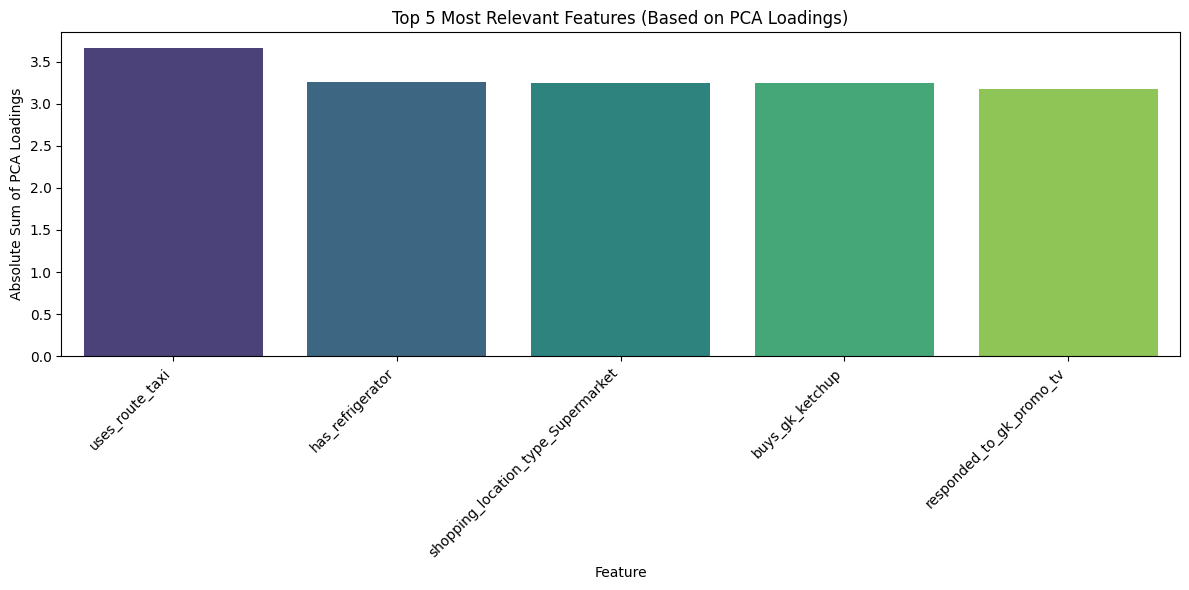

In [49]:
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance_pca.head(5).index, y=feature_importance_pca.head(5).values, palette='viridis')
plt.title('Top 5 Most Relevant Features (Based on PCA Loadings)')
plt.xlabel('Feature')
plt.ylabel('Absolute Sum of PCA Loadings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [43]:
sse = []
k_rng = range(1, 10)
for k in k_rng:
    km = KMeans(n_clusters = k, random_state = 42, n_init=10)
    km.fit(data_scaled)
    sse.append(km.inertia_)

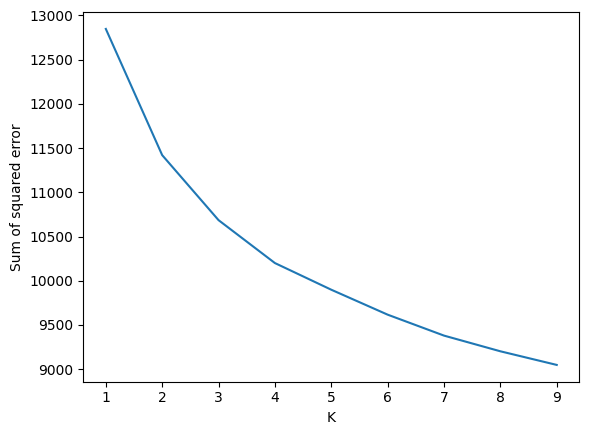

In [44]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)

In [45]:
km_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_pca = km_pca.fit_predict(data_pca)

# Add the new labels to our original dataframe for profiling
data['cluster_label_pca'] = clusters_pca
display(data.head())

,age,weekly_household_income_jmd,num_children_under_12,num_teens_at_home,months_as_gk_customer,days_since_last_purchase,mnt_tinned_meats_monthly_jmd,mnt_baked_goods_monthly_jmd,mnt_gk_juices_monthly_jmd,mnt_saltfish_tinned_fish_monthly_jmd,mnt_fresh_produce_monthly_jmd,mnt_cooking_oil_monthly_jmd,buys_gk_ketchup,buys_festival_dumpling_mix,num_supermarket_visits_monthly,num_market_vendor_visits_monthly,num_promo_purchases_monthly,uses_route_taxi,has_refrigerator,responded_to_gk_promo_tv,responded_to_gk_promo_radio,responded_to_gk_promo_social,gk_brand_loyalty_score,filed_complaint,education_encoded,marital_status_Married,marital_status_Separated,marital_status_Single,preferred_cooking_oil_Grace,preferred_cooking_oil_Mazola,preferred_cooking_oil_Other/Generic,parish_Kingston,parish_Manchester,parish_Other,parish_St. Andrew,parish_St. Catherine,parish_St. Elizabeth,parish_St. James,shopping_location_type_Corner Shop,shopping_location_type_Market/Higglar,shopping_location_type_Mixed,shopping_location_type_Supermarket,shopping_location_type_Wholesale/Chinese Shop,cluster_label_pca
0,35,17489,2,2,28,10,3293.73,1889.34,2369.11,1331.81,3727.26,465.48,1,1,6,1,4,0,1,1,0,1,5,0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
1,40,29645,0,1,13,17,2581.46,1446.95,1586.07,1108.04,3481.68,584.06,1,1,6,3,1,0,1,1,1,1,4,0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,31,12983,0,0,43,6,1153.51,450.01,616.11,869.49,2171.21,502.14,1,0,4,3,5,1,1,1,1,0,4,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
3,32,7382,0,3,35,4,1803.64,945.08,896.75,912.75,1633.19,421.51,1,0,4,4,5,0,1,0,0,0,5,0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,52,6035,0,1,16,2,831.54,232.27,230.71,516.67,811.68,228.91,0,1,1,5,1,1,1,0,1,1,4,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3


In [46]:
from sklearn.metrics import silhouette_score
score = silhouette_score(data_pca, clusters_pca)
print(f"Silhouette Score after PCA reduction: {score:.4f}")

Silhouette Score after PCA reduction: 0.0945


### Visualizing PCA-based Clusters
We project the high-dimensional clusters onto the first two principal components for a 2D visualization.

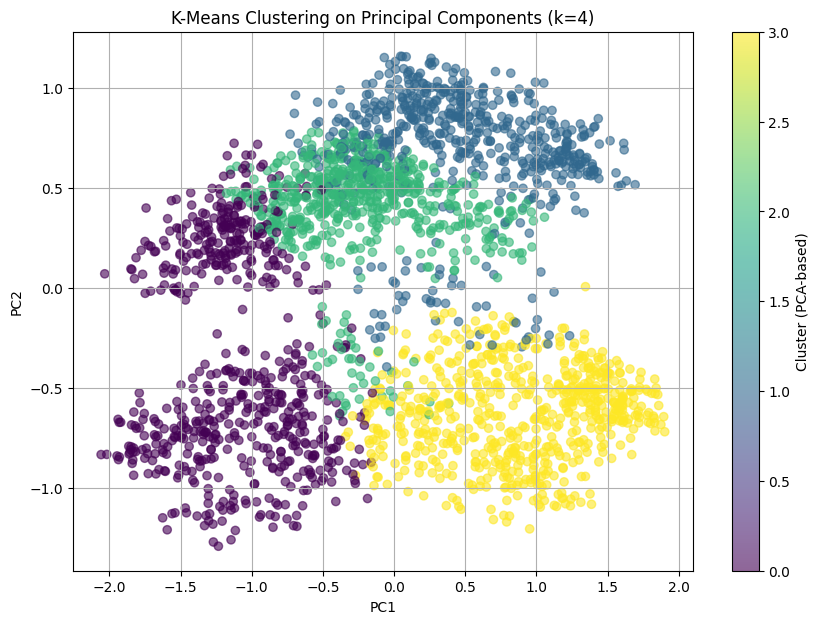

In [47]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters_pca, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster (PCA-based)')
plt.title('K-Means Clustering on Principal Components (k=4)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

### Business Profiling of PCA Clusters
We compare the mean values of key metrics across the four clusters to define their business characteristics.

In [48]:
key_metrics = ['age', 'weekly_household_income_jmd', 'mnt_gk_juices_monthly_jmd', 'num_supermarket_visits_monthly', 'gk_brand_loyalty_score']
pca_profile = data.groupby('cluster_label_pca')[key_metrics].mean()
display(pca_profile)

,age,weekly_household_income_jmd,mnt_gk_juices_monthly_jmd,num_supermarket_visits_monthly,gk_brand_loyalty_score
cluster_label_pca,,,,,
0,40.078247,37462.749609,2855.091565,6.845070,4.123631
1,40.006849,10821.486301,881.205360,3.035959,3.626712
2,37.686084,12896.281553,1086.477120,3.713592,3.778317
3,43.470410,7773.928680,534.990349,2.135053,3.242792


### Summary of Segment Characteristics
The table above provides the business profile for each of our 4 PCA-derived clusters.

### Business Profiling of PCA Clusters
We compare the mean values of key metrics across the four clusters to define their business characteristics.

##RECHECK LATER

In [42]:
km = KMeans(n_clusters = 4)
predicted_cluster = km.fit_predict(data_scaled)
predicted_cluster

array([3, 3, 2, ..., 2, 1, 2], dtype=int32)

In [43]:
data['cluster_label'] = predicted_cluster
data.head()

,age,weekly_household_income_jmd,num_children_under_12,num_teens_at_home,months_as_gk_customer,days_since_last_purchase,mnt_tinned_meats_monthly_jmd,mnt_baked_goods_monthly_jmd,mnt_gk_juices_monthly_jmd,mnt_saltfish_tinned_fish_monthly_jmd,mnt_fresh_produce_monthly_jmd,mnt_cooking_oil_monthly_jmd,buys_gk_ketchup,buys_festival_dumpling_mix,num_supermarket_visits_monthly,num_market_vendor_visits_monthly,num_promo_purchases_monthly,uses_route_taxi,has_refrigerator,responded_to_gk_promo_tv,responded_to_gk_promo_radio,responded_to_gk_promo_social,gk_brand_loyalty_score,filed_complaint,education_encoded,marital_status_Married,marital_status_Separated,marital_status_Single,preferred_cooking_oil_Grace,preferred_cooking_oil_Mazola,preferred_cooking_oil_Other/Generic,parish_Kingston,parish_Manchester,parish_Other,parish_St. Andrew,parish_St. Catherine,parish_St. Elizabeth,parish_St. James,shopping_location_type_Corner Shop,shopping_location_type_Market/Higglar,shopping_location_type_Mixed,shopping_location_type_Supermarket,shopping_location_type_Wholesale/Chinese Shop,cluster_label_pca,cluster_label
0,35,17489,2,2,28,10,3293.73,1889.34,2369.11,1331.81,3727.26,465.48,1,1,6,1,4,0,1,1,0,1,5,0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,3
1,40,29645,0,1,13,17,2581.46,1446.95,1586.07,1108.04,3481.68,584.06,1,1,6,3,1,0,1,1,1,1,4,0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,3
2,31,12983,0,0,43,6,1153.51,450.01,616.11,869.49,2171.21,502.14,1,0,4,3,5,1,1,1,1,0,4,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,2
3,32,7382,0,3,35,4,1803.64,945.08,896.75,912.75,1633.19,421.51,1,0,4,4,5,0,1,0,0,0,5,0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,2
4,52,6035,0,1,16,2,831.54,232.27,230.71,516.67,811.68,228.91,0,1,1,5,1,1,1,0,1,1,4,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3,2


In [44]:
km.cluster_centers_

array([[ 4.66172261e-01,  6.52318763e-02,  3.89929742e-01,
         2.57611241e-01,  3.21576705e-01,  1.33560429e-01,
         2.19932832e-01,  1.02325692e-01,  9.24543868e-02,
         1.69879466e-01,  1.39479881e-01,  1.99011700e-01,
         7.49414520e-01,  4.56674473e-01,  1.80913349e-01,
         5.04215457e-01,  4.51756440e-01,  8.50117096e-01,
         5.97189696e-01,  3.58313817e-01,  5.57377049e-01,
         2.31850117e-01,  5.74941452e-01,  6.32318501e-02,
         3.93442623e-01,  8.40749415e-01,  1.59250585e-01,
        -3.05311332e-15,  1.38173302e-01,  7.02576112e-02,
         7.91569087e-01,  1.19437939e-01,  7.96252927e-02,
         2.48243560e-01,  1.21779859e-01,  9.60187354e-02,
         2.66978923e-01,  6.79156909e-02,  2.99765808e-01,
         3.62997658e-01,  1.05386417e-01,  7.49414520e-02,
         1.56908665e-01],
       [ 3.34374244e-01,  1.29695620e-01,  3.71241830e-01,
         2.77559913e-01,  3.36278447e-01,  2.26698356e-01,
         3.28912901e-01,  1.77

In [45]:
from sklearn.pipeline import Pipeline
import joblib

# Define the pipeline with the specific parameters we found optimal
segmentation_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=22, random_state=42)),
    ('kmeans', KMeans(n_clusters=4, random_state=42, n_init=10))
])

# Fit the pipeline on the original encoded data (pre-scaling)
# Note: We use the data BEFORE MinMaxScaler because the pipeline handles it now
segmentation_pipeline.fit(data.drop(columns=['cluster_label', 'cluster_label_pca'], errors='ignore'))

# Save the model to Google Drive
model_path = '/content/drive/MyDrive/gk_customer_segmentation_model.joblib'
joblib.dump(segmentation_pipeline, model_path)

print(f"Model successfully packaged and saved to: {model_path}")

Model successfully packaged and saved to: /content/drive/MyDrive/gk_customer_segmentation_model.joblib


## Model Evaluation


In [46]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# 1. Silhouette Score: Measures how similar an object is to its own cluster compared to other clusters
sil_score = silhouette_score(data_pca, clusters_pca)

# 2. Calinski-Harabasz Index: Ratio of the sum of between-clusters dispersion and of within-cluster dispersion
ch_index = calinski_harabasz_score(data_pca, clusters_pca)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")

Silhouette Score: 0.0945
Calinski-Harabasz Index: 243.44


## Geospatial Analysis: High-Value Customer Density
We will now visualize the geographical distribution of Segment 0 (Premium) customers across Jamaica using a Choropleth map.

In [48]:
import json

file_path = '/content/drive/MyDrive/jm.json'

with open(file_path) as f:
    geo = json.load(f)

# Check the structure to ensure we have the correct keys for the map
print("First feature properties:", geo['features'][0]['properties'])

First feature properties: {'source': 'https://simplemaps.com', 'id': 'JM06', 'name': 'Saint Ann'}


In [49]:
#exact names in 'geo' object
print([feature['properties']['name'] for feature in geo['features']])

['Saint Ann', 'Trelawny', 'Saint James', 'Hanover', 'Westmoreland', 'Saint Elizabeth', 'Manchester', 'Clarendon', 'Saint Catherine', 'Saint Andrew', 'Kingston', 'Saint Thomas', 'Portland', 'Saint Mary']


In [50]:
import pandas as pd

# 1. Get names from GeoJSON
geojson_names = sorted([feature['properties']['name'] for feature in geo['features']])

# 2. Get names from your DataFrame
parish_cols = [col for col in data.columns if col.startswith('parish_')]
data_parish_names = sorted([col.replace('parish_', '').replace('_', ' ').title() for col in parish_cols])

print("--- Names in GeoJSON ---")
print(geojson_names)
print("\n--- Names in your Data (after .title()) ---")
print(data_parish_names)

# 3. Check for mismatches
mismatches = set(data_parish_names) - set(geojson_names)
if mismatches:
    print(f"\n⚠️ MISMATCH FOUND: These names in your data are not in the GeoJSON: {mismatches}")
else:
    print("\n✅ SUCCESS: All names match perfectly!")

--- Names in GeoJSON ---
['Clarendon', 'Hanover', 'Kingston', 'Manchester', 'Portland', 'Saint Andrew', 'Saint Ann', 'Saint Catherine', 'Saint Elizabeth', 'Saint James', 'Saint Mary', 'Saint Thomas', 'Trelawny', 'Westmoreland']

--- Names in your Data (after .title()) ---
['Kingston', 'Manchester', 'Other', 'St. Andrew', 'St. Catherine', 'St. Elizabeth', 'St. James']

⚠️ MISMATCH FOUND: These names in your data are not in the GeoJSON: {'St. Andrew', 'St. Elizabeth', 'St. James', 'Other', 'St. Catherine'}


In [51]:
# Prepare parish columns
parish_cols = [col for col in data.columns if col.startswith('parish_')]

# Mapping to match GeoJSON exactly
parish_map = {
    'St. Andrew': 'Saint Andrew',
    'St. Catherine': 'Saint Catherine',
    'St. Elizabeth': 'Saint Elizabeth',
    'St. James': 'Saint James'
}

# Initialize map
m = folium.Map(
    location=[18.1096, -77.2975],
    zoom_start=9,
    tiles='cartodbpositron'
)

# Loop through clusters
for cluster in sorted(data['cluster_label_pca'].unique()):
    cluster_dist = (
        data[data['cluster_label_pca'] == cluster][parish_cols]
        .sum()
        .reset_index()
    )
    cluster_dist.columns = ['parish', 'count']

    # Clean and Map parish names
    cluster_dist['parish'] = (
        cluster_dist['parish']
        .str.replace('parish_', '')
        .str.replace('_', ' ')
        .str.title()
    )
    cluster_dist['parish'] = cluster_dist['parish'].replace(parish_map)

    # Remove 'Other' as it's not a geographic parish in the GeoJSON
    cluster_dist = cluster_dist[cluster_dist['parish'] != 'Other']

    cluster_dist['count'] = cluster_dist['count'].fillna(0)

    # Add Choropleth per cluster
    folium.Choropleth(
        geo_data=geo,
        data=cluster_dist,
        columns=['parish', 'count'],
        key_on='feature.properties.name',
        fill_color='YlOrRd',
        fill_opacity=0.4,
        line_opacity=0.2,
        nan_fill_color='white',
        highlight=True,
        name=f'Cluster {cluster}',
        show=(cluster == 0)
    ).add_to(m)

# Add parish borders + tooltip
folium.GeoJson(
    geo,
    name="Parish Borders",
    style_function=lambda x: {
        'fillColor': 'transparent',
        'color': '#444',
        'weight': 0.5
    },
    tooltip=folium.features.GeoJsonTooltip(
        fields=['name'],
        aliases=['Parish:'],
        localize=True
    )
).add_to(m)

# Minimal legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999; background: white; padding: 10px 12px; border-radius: 8px; box-shadow: 0 2px 8px rgba(0,0,0,0.15); font-family: Arial; font-size: 12px; line-height: 1.6;">
<b style="font-size:13px;">Clusters</b><br>
<span style="display:inline-block;width:10px;height:10px;background:#1b9e77;border-radius:2px;"></span> Cluster 0<br>
<span style="display:inline-block;width:10px;height:10px;background:#d95f02;border-radius:2px;"></span> Cluster 1<br>
<span style="display:inline-block;width:10px;height:10px;background:#7570b3;border-radius:2px;"></span> Cluster 2<br>
<span style="display:inline-block;width:10px;height:10px;background:#e7298a;border-radius:2px;"></span> Cluster 3<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)

m.save('jamaica_clusters_map.html')
m

### Final Verdict on Model Utility
* **Good:** Each segment represents at least 15-35% of your base. No segment is too small to ignore, and none is so large that it's just 'everyone'.
* **Useful:** You can now tailor GraceKennedy marketing.
    * **PC1 High:** Focus on radio ads and 'on-the-go' value meals (route taxi users).
    * **PC2 High:** Focus on Grace-branded loyalty bundles and tradition-based marketing (Grace Oil & Festival Mix lovers).

### Business Validation Checklist
A model is 'good' in a retail context if it meets these criteria:
1. **Substantiality:** Are the segments large enough to be worth targeting? (Check `data['cluster_label_pca'].value_counts()`)
2. **Differentiability:** Do the segments respond differently to marketing? (e.g., Segment 0 prefers Grace, Segment 3 prefers Generic)
3. **Actionability:** Can we actually find these people? (e.g., We can find Segment 3 by advertising at route taxi stands since they are top contributors to PC1).
4. **Stability:** If you take a new sample of data, do the same segments reappear?

##Model Packaging

### How to use the packaged model

In a new environment, you can load and use the model like this:

```python
import joblib
loaded_model = joblib.load('gk_customer_segmentation_model.joblib')

# Assuming 'new_data' is a DataFrame with the same 43 features
new_clusters = loaded_model.predict(new_data)
```